In [18]:
!pip install -q torchattacks
!pip install git+https://github.com/fra31/auto-attack.git
!pip install git+https://github.com/RobustBench/robustbench.git --no-deps

  Cloning https://github.com/fra31/auto-attack.git to /tmp/pip-req-build-lyic1q4x
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-req-build-lyic1q4x
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/RobustBench/robustbench.git to /tmp/pip-req-build-5wbd88qc
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /tmp/pip-req-build-5wbd88qc
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Preparing metadata (setup.py) ... done


In [19]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

import torchattacks
from robustbench.utils import load_model

In [20]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [21]:
BATCH_SIZE = 128
NUM_WORKERS = 2
DATA_ROOT = "/content/data"
PIN_MEMORY = torch.cuda.is_available()

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=raw_transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [23]:
print("Loading RobustBench Models...")

# Loading state-of-the-art models representing the 4 categories
models = {
    "Clean (Standard)": load_model(
        model_name='Standard', dataset='cifar10', threat_model='Linf'
    ).to(device).eval(),

    "Adversarial Training": load_model(
        model_name='Carmon2019Unlabeled', dataset='cifar10', threat_model='Linf'
    ).to(device).eval(),

    #"Randomized Smoothing": load_model(
    #    model_name='Salman2020Do_R18', dataset='cifar10', threat_model='L2'
    #).to(device).eval(),
    #
    "Diffusion Purification": load_model(
        model_name='Wang2023Better_WRN-28-10', dataset='cifar10', threat_model='Linf'
    ).to(device).eval()
}

Loading RobustBench Models...


Downloading...
From (original): https://drive.google.com/uc?id=1-6MYKJdECDVGaWjj6GgqvaT95BGKhUvI
From (redirected): https://drive.google.com/uc?id=1-6MYKJdECDVGaWjj6GgqvaT95BGKhUvI&confirm=t&uuid=2675ae65-8014-4631-8ebc-f0853569d2c8
To: /content/models/cifar10/Linf/Wang2023Better_WRN-28-10.pt
100%|██████████| 146M/146M [00:01<00:00, 117MB/s]


In [24]:
def evaluate_models_and_attacks(models_dict, loader, device, max_samples=1000):
    results = {}

    for model_name, model in models_dict.items():
        print(f"\n--- Evaluating Model: {model_name} ---")
        results[model_name] = {}

        attacks = {
            "Clean": None,
            "FGSM": torchattacks.FGSM(model, eps=8/255),
            "PGD": torchattacks.PGD(model, eps=8/255, alpha=2/255, steps=10),
            "DeepFool": torchattacks.DeepFool(model, steps=10),
            "C&W": torchattacks.CW(model, c=1, kappa=0, steps=50, lr=0.01)
        }

        for atk_name, atk in attacks.items():
            total_correct = 0
            total_samples = 0

            for images, labels in loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

                if atk_name == "Clean":
                    adv_images = images
                else:
                    adv_images = atk(images, labels)

                with torch.no_grad():
                    logits = model(adv_images)
                    preds = logits.argmax(dim=1)

                total_correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

                if max_samples and total_samples >= max_samples:
                    break

            accuracy = total_correct / total_samples
            results[model_name][atk_name] = accuracy
            print(f"Accuracy vs {atk_name}: {accuracy:.4f}")

    return results

In [25]:
results_matrix = evaluate_models_and_attacks(models, test_loader, device, max_samples=1000)

df_results = pd.DataFrame(results_matrix).T
df_results


--- Evaluating Model: Clean (Standard) ---
Accuracy vs Clean: 0.9473
Accuracy vs FGSM: 0.3027
Accuracy vs PGD: 0.0000
Accuracy vs DeepFool: 0.0273
Accuracy vs C&W: 0.0039

--- Evaluating Model: Adversarial Training ---
Accuracy vs Clean: 0.9023
Accuracy vs FGSM: 0.7080
Accuracy vs PGD: 0.6387
Accuracy vs DeepFool: 0.0020
Accuracy vs C&W: 0.3008

--- Evaluating Model: Diffusion Purification ---
Accuracy vs Clean: 0.9326
Accuracy vs FGSM: 0.7607
Accuracy vs PGD: 0.7246
Accuracy vs DeepFool: 0.0088
Accuracy vs C&W: 0.3369


,Clean,FGSM,PGD,DeepFool,C&W
Clean (Standard),0.947266,0.302734,0.000000,0.027344,0.003906
Adversarial Training,0.902344,0.708008,0.638672,0.001953,0.300781
Diffusion Purification,0.932617,0.760742,0.724609,0.008789,0.336914


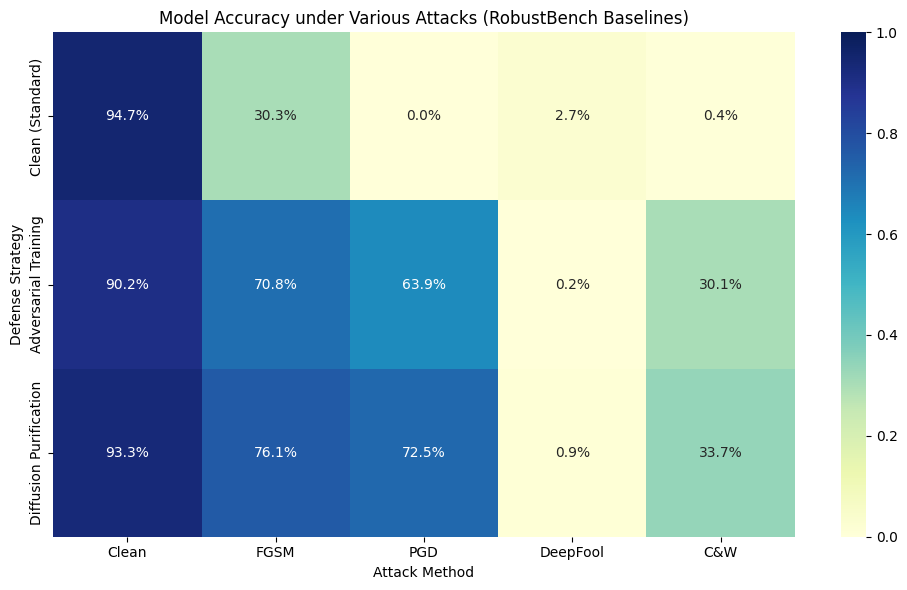

In [26]:
# Heatmap Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(df_results, annot=True, cmap="YlGnBu", fmt=".1%", vmin=0, vmax=1)
plt.title("Model Accuracy under Various Attacks (RobustBench Baselines)")
plt.ylabel("Defense Strategy")
plt.xlabel("Attack Method")
plt.tight_layout()
plt.show()

In [ ]:
# Grouped Bar Chart Visualization
df_results.plot(kind="bar", figsize=(12, 6), width=0.8)
plt.title("Adversarial Robustness Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Defense Strategy")
plt.legend(title="Attacks", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()